# MATH 210 Introduction to Mathematical Computing

**March 6, 2026**

* Examples
* `scipy.integrate`: `trapezoid`, `simpson` and `quad`

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi

## Example

Approximate the integral $$\int_0^1 e^{\cos(\pi x)} dx$$

Compute derivatives of $f(x) = e^{\cos(\pi x)}$:

$$
f'(x) = -\pi \sin(\pi x) e^{\cos(\pi x)} \hspace{10mm}
f''(x) =  \pi^2 \sin^2(\pi x) e^{\cos(\pi x)} -\pi^2 \cos(\pi x) e^{\cos(\pi x)}
$$

Plot graphs:

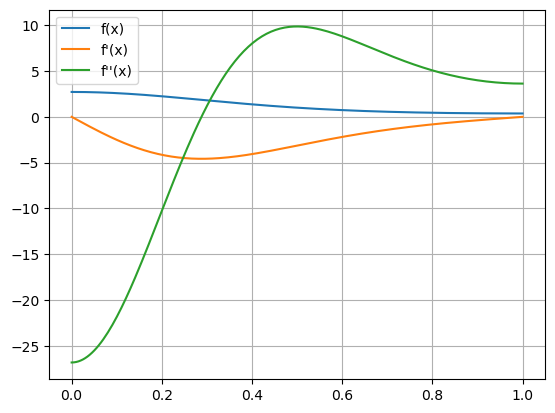

In [64]:
x = np.linspace(0,1,200)
f = lambda x: np.exp(np.cos(np.pi*x))
df = lambda x: -np.pi*np.sin(np.pi*x)*np.exp(np.cos(np.pi*x))
ddf = lambda x: np.pi**2*np.sin(np.pi*x)**2*np.exp(np.cos(np.pi*x)) - np.pi**2*np.cos(np.pi*x)*np.exp(np.cos(np.pi*x))
plt.plot(x,f(x),x,df(x),x,ddf(x)),plt.legend(["f(x)","f'(x)","f''(x)"]), plt.grid(True)
plt.show()

In [65]:
K1 = np.max(np.abs(df(x)))
print(K1)

4.581988928046055


In [66]:
K2 = np.pi**2*np.e
print(K2)

26.828366297560617


In [70]:
a = 0; b = 1; N = 1000; dx = (b - a)/N;
x = np.linspace(a,b,N+1)
y = f(x)

L = dx*np.sum(y[:-1])
EL = (b - a)**2*K1/(2*N)
print("Left Riemann sum:",L,"+-",EL)

R = dx*np.sum(y[1:])
ER = (b - a)**2*K1/2/N
print("Right Riemann sum:",R,"+-",ER)

T = (L + R)/2 # dx*np.sum(y[:-1] + y[1:])/2
ET = (b - a)**3*K2/12/N**2
print("Trapezoid rule:",T,"+-",ET)

Left Riemann sum: 1.267241078945652 +- 0.0022909944640230277
Right Riemann sum: 1.2648906765583647 +- 0.0022909944640230277
Trapezoid rule: 1.2660658777520084 +- 2.2356971914633847e-06


## `scipy.integrate`

The subpackage `scipy.integrate` has several functions for computing integrals:

In [79]:
import scipy.integrate as spi

In [80]:
a = 0; b = 1; N = 1000; dx = (b - a)/N;
x = np.linspace(a,b,N+1)
y = f(x)
T1 = dx*np.sum(y[1:] + y[:-1])/2
T2 = spi.trapezoid(y,x)
print(T1,T2)

1.2660658777520084 1.2660658777520084


In [81]:
def trapezoid(y,x):
    dx = (x[-1] - x[0])/(len(x) - 1)
    T = dx*np.sum(y[1:] + y[:-1])/2
    return T

In [82]:
T = trapezoid(y,x)
print(T)

1.2660658777520084


This only works for equally spaces $x$ values. What if they're not?!

In [83]:
def trapezoid(y,x):
    T = np.sum((y[1:] + y[:-1])*(x[1:] - x[:-1]))/2
    return T

In [84]:
T = trapezoid(y,x)
print(T)

1.2660658777520084


Look at the documentation for function `spi.quad`.

In [ ]:
spi.quad?

In [85]:
a = 0; b = 1;
f = lambda x: np.exp(np.cos(np.pi*x))
result = spi.quad(f,a,b)

The function returns a tuple where the first entry is the approximation of $\int_a^b f(x)dx$ and the second value is a bound on the error.

In [86]:
type(result)

tuple

In [87]:
print(result)

(1.2660658777520084, 3.877952221772689e-12)


We can unpack the tuple and assign the first value to `I` and the second to `E`.

In [88]:
I,E = spi.quad(f,0,1)
print(I,"+-",E)

1.2660658777520084 +- 3.877952221772689e-12


Let's try the famous integral

$$
\int_0^{\infty} e^{-x^2} dx = \frac{\sqrt{\pi}}{2}
$$

In [89]:
f = lambda x: np.exp(-x**2)
I,E = spi.quad(f,0,np.inf)
print(I,"+-",E)

0.8862269254527579 +- 7.101318390472462e-09


In [91]:
print(np.sqrt(np.pi)/2)

0.8862269254527579
